In [102]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import torch.nn.functional as F 
from collections import OrderedDict
from dataLoaders import load_train_val, load_test
from CustomNeuralNetwork import customNet


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:

x_train, x_val, y_train, y_val = load_train_val(pytorch=True)

# print(x_train[0])    
print(f"number of training samples: {len(x_train)}")    
print(f"Input Images size: {x_train[0].shape}")

number of training samples: 10200
Input Images size: torch.Size([784])


In [104]:
INPUT_DATA_SIZE = 784
NUM_CLASSES = 10
LEARNING_RATE = 0.03


myNet = customNet(INPUT_DATA_SIZE, NUM_CLASSES, LEARNING_RATE)


In [105]:
myNet.initializeWeights()


In [106]:
myNet.emptyLists()

In [107]:
batch_size = 64
epochs = 30

myNet.train(x_train, y_train, x_val, y_val, batch_size=batch_size, epochs=epochs)


-> Epoch 1, Total Loss: 0.8885941213031985,  Total Evaluation Loss: 0.4910658299922943
-> Model Training accuracy: 0.7635294117647059,  Model Evaluation Accuracy: 0.8654016064257029 

-> Epoch 2, Total Loss: 0.42258384017824374,  Total Evaluation Loss: 0.3732052147388458
-> Model Training accuracy: 0.8858823529411765,  Model Evaluation Accuracy: 0.8933132530120482 

-> Epoch 3, Total Loss: 0.3395537697481659,  Total Evaluation Loss: 0.3279986083507538
-> Model Training accuracy: 0.9055882352941177,  Model Evaluation Accuracy: 0.9054819277108433 

-> Epoch 4, Total Loss: 0.29613152699275586,  Total Evaluation Loss: 0.3017908036708832
-> Model Training accuracy: 0.9157843137254902,  Model Evaluation Accuracy: 0.9119477911646586 

-> Epoch 5, Total Loss: 0.2662191273843717,  Total Evaluation Loss: 0.28336629271507263
-> Model Training accuracy: 0.9236274509803921,  Model Evaluation Accuracy: 0.9167871485943775 

-> Epoch 6, Total Loss: 0.2428718757048343,  Total Evaluation Loss: 0.2691440

In [108]:

trainingLoss = myNet.getTrainingLoss()
validationLoss = myNet.getValidationLoss()

trainAccuracy = myNet.getTrainAccuracy()
valAccuracy = myNet.getValAccuracy()

epochs = list(range(1, len(trainingLoss)+1))
print(epochs)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


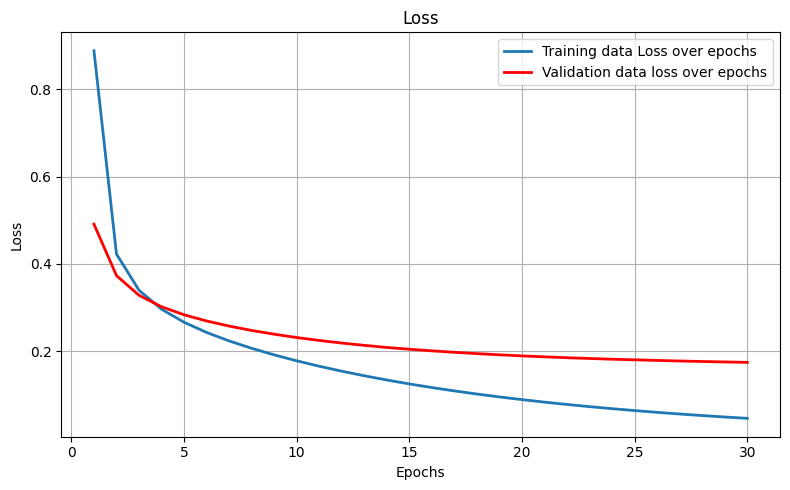

In [112]:

from helperPlots import plot_two_curves

plot_two_curves(epochs, trainingLoss, validationLoss, "Training data Loss over epochs", "Validation data loss over epochs", "Loss", "Epochs", "Loss")

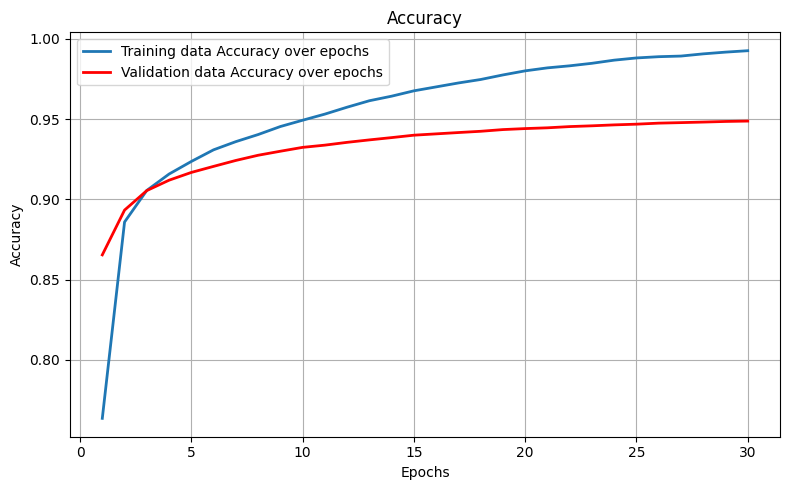

In [113]:
plot_two_curves(epochs, trainAccuracy, valAccuracy, "Training data Accuracy over epochs", "Validation data Accuracy over epochs", "Accuracy", "Epochs", "Accuracy")

In [114]:
myNet.predict(x_train[10]).max().item()
# print(y_train[10])

8.070429801940918